# Quantum Computing Hands-on: A Tutorial for Neuroscientists

*Paired with the "Introduction to Quantum Computing" talk by L. Knowles (FAU).*

**Goal:** in the next ~25 minutes, you'll build your first quantum program, 
see entanglement with your own eyes, and run an algorithm that's provably faster 
than any classical one. No prior quantum experience required — but you should be 
comfortable reading Python.

**Running this notebook:**
- Easiest: open in [Google Colab](https://colab.research.google.com) — no install needed.
- Locally: `pip install qiskit qiskit-aer matplotlib numpy` then `jupyter notebook`.

**The plan:**
1. **Setup** — install Qiskit, check it works.
2. **Exercise 1** — build and measure one qubit.
3. **Exercise 2** — create an entangled pair (Bell state).
4. **Exercise 3** — 3-qubit superposition (quantum parallelism).
5. **Exercise 4** — the Deutsch–Jozsa algorithm (real quantum speedup).
6. **Bonus** — things to try if you have time left.


## 0. Setup

Run the next cell. In Colab it takes ~30 seconds.

In [1]:
# Install Qiskit (only needed on Colab or fresh environments)
try:
    import qiskit
    import qiskit_aer
except ImportError:
    !pip install -q qiskit qiskit-aer matplotlib numpy

# Standard imports
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram, plot_bloch_multivector
from qiskit.quantum_info import Statevector

print('Qiskit version:', qiskit.__version__)
print('Ready to go.')


Qiskit version: 2.4.0
Ready to go.


---
## Exercise 1 — Build your first qubit

**What we're doing:** A qubit starts in state $|0\rangle$. We'll apply a **Hadamard gate** 
(`H`) to put it into an equal superposition, then measure it 1000 times and see what 
fraction comes out 0 vs 1.

**Expected result:** ~50% each. You wrote a 50/50 superposition; you see a 50/50 outcome.

**Neuro analogy:** this is like recording one neuron with stochastic firing for 1000 trials.
Each individual trial gives you a deterministic 0 or 1 — the structure lives in the distribution.


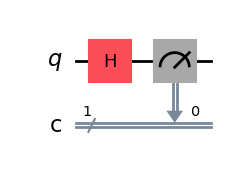

In [2]:
# Create a 1-qubit circuit with 1 classical bit for the measurement result
qc = QuantumCircuit(1, 1)

# TODO: apply a Hadamard gate to qubit 0
#       (hint: qc.h(0))


# TODO: measure qubit 0 and store the result in classical bit 0
#       (hint: qc.measure(0, 0))


qc = QuantumCircuit(1, 1)

qc.h(0)              # Hadamard on qubit 0
qc.measure(0, 0)     # measure qubit 0 into classical bit 0

qc.draw('mpl')

# Draw the circuit to check it looks right
qc.draw('mpl')


Outcome counts: {'0': 492, '1': 508}


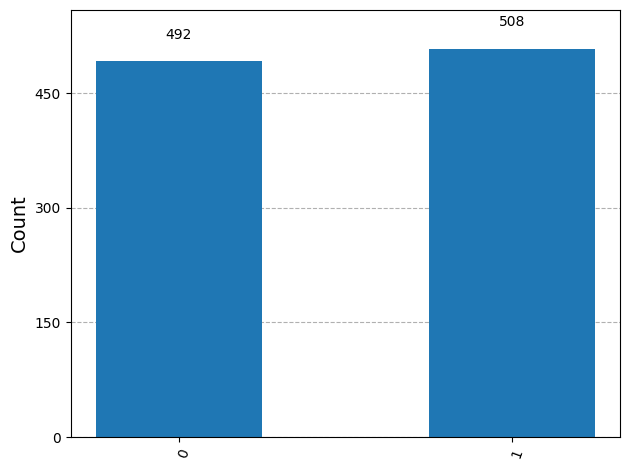

In [3]:
# Run it 1000 times on a simulator and count outcomes
simulator = AerSimulator()
result = simulator.run(qc, shots=1000).result()

counts = result.get_counts()

print('Outcome counts:', counts)
plot_histogram(counts)


**What just happened?** You prepared the state
$$|\psi\rangle = \tfrac{1}{\sqrt 2}|0\rangle + \tfrac{1}{\sqrt 2}|1\rangle$$
The amplitudes are both $1/\sqrt{2}$, so $|\alpha|^2 = |\beta|^2 = 0.5$. That's why the 
histogram is ~50/50.

**Try it:** replace `qc.h(0)` with `qc.rx(np.pi/3, 0)` (a rotation by 60°) and re-run. 
The probabilities should change in a predictable way. What do you see?


---
## Exercise 2 — Entanglement (the Bell state)

**What we're doing:** we'll create the famous Bell state
$$|\Phi^+\rangle = \tfrac{1}{\sqrt 2}\big(|00\rangle + |11\rangle\big)$$
Two qubits, perfectly correlated. If you measure one and get 0, the other will be 0. 
If you measure one and get 1, the other will be 1. *Always.* But individually, each 
qubit is 50/50 random.

**Recipe:** apply Hadamard to qubit 0, then CNOT with qubit 0 as control and qubit 1 as target.

**Expected result:** you'll see ~50% `00` and ~50% `11`, and never `01` or `10`.


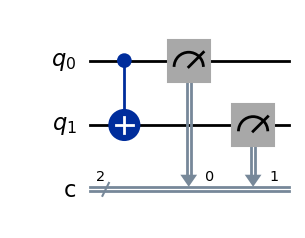

In [4]:
qc = QuantumCircuit(2, 2)

# TODO: apply H to qubit 0   (hint: qc.h(0))

#qc.h(0)              # Hadamard on qubit 0


# TODO: apply CNOT with qubit 0 as control, qubit 1 as target
#       (hint: qc.cx(0, 1))

qc.cx(0, 1)           # CNOT with qubit 0 as control and qubit 1 as target

# Measure both qubits
qc.measure([0, 1], [0, 1])

qc.draw('mpl')


Outcome counts: {'00': 1000}


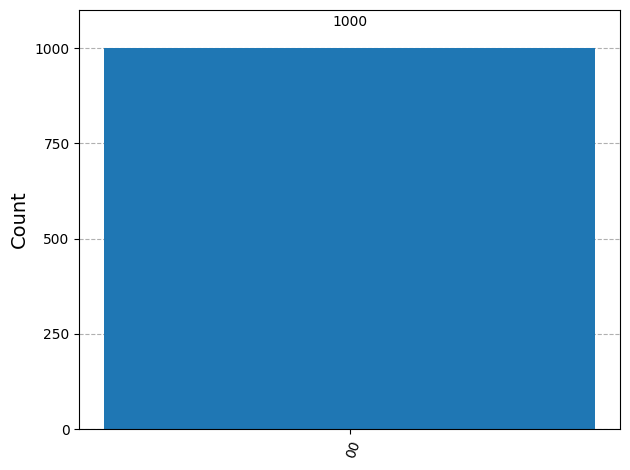

In [5]:
# Run and plot
result = AerSimulator().run(qc, shots=1000).result()
counts = result.get_counts()
print('Outcome counts:', counts)
plot_histogram(counts)


**What just happened?** You should see only `00` and `11` — roughly 500 each — and 
essentially zero `01` or `10`. The two qubits aren't independent: they're **entangled**.

This is the weirdest thing in quantum mechanics and also the thing that makes quantum 
computing work. The correlations between qubits carry information that no product of 
independent qubits could carry.

**Bell's theorem, in one line:** no classical theory where each qubit has a definite 
pre-existing value (even if we don't know it yet) can reproduce these statistics in 
general. This has been experimentally verified. It won the 2022 Nobel Prize in Physics.


---
## Exercise 3 — Quantum parallelism (n Hadamards → 2ⁿ states)

**What we're doing:** we'll put 3 qubits into a uniform superposition over all 8 
possible basis states in just 3 gates. This is the magic-trick slide from the talk, 
made concrete.

**Expected result:** histogram with 8 bars, each about 12.5%.


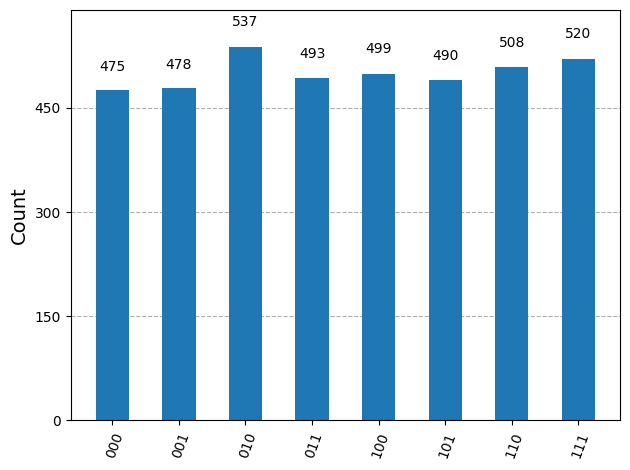

In [6]:
n = 3
qc = QuantumCircuit(n, n)

# TODO: apply Hadamard to EACH of the n qubits
#       hint: use a for loop, e.g.
#           for i in range(n):
#               qc.h(i)

for i in range(n):
    qc.h(i)


# Measure all qubits
qc.measure(range(n), range(n))

# Run it
result = AerSimulator().run(qc, shots=4000).result()
counts = result.get_counts()
plot_histogram(counts)


**What just happened?** Three Hadamard gates produced a uniform superposition over 
all $2^3 = 8$ possible 3-bit strings. Measurement gives each with equal probability ~1/8.

**Scale it up:** change `n = 3` to `n = 10`. That's a uniform superposition over 1024 
states, built in 10 gates. At `n = 20` the histogram has a million bars. At `n = 50`, 
your classical laptop can't store the state anymore.


---
## Exercise 4 — The Deutsch–Jozsa algorithm

This is the payoff exercise. You're going to implement the **first quantum algorithm 
ever shown to be provably faster than any classical algorithm** (Deutsch & Jozsa, 1992).

**The problem.** Imagine someone gives you a black-box function $f$ that takes an 
$n$-bit input and returns 0 or 1. They promise $f$ is one of two types:
- **constant** — returns the same value (all 0s or all 1s) for every input, *or*
- **balanced** — returns 0 for exactly half of inputs and 1 for the other half.

Your job: figure out which type it is.

**Classical cost:** worst case, you need to query $2^{n-1}+1$ inputs to be sure. 
(If the first $2^{n-1}$ all return the same answer, it could still go either way.)

**Quantum cost:** exactly 1 query. Always.

We'll do this with $n=3$, so 3 input qubits + 1 ancilla qubit = 4 qubits total.


### Step 1 — Build a "balanced" oracle

The oracle $U_f$ maps $|x\rangle|y\rangle \to |x\rangle|y \oplus f(x)\rangle$. 
We'll make a simple balanced function: $f(x) = x_0 \oplus x_1 \oplus x_2$ (parity). 
Half the inputs give 0, half give 1 — that's balanced by construction.

To implement it: apply CNOT from each input qubit to the ancilla. XOR accumulates.


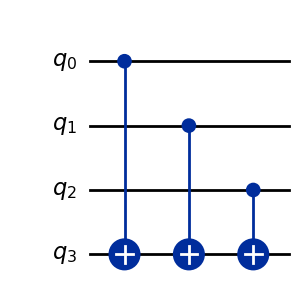

In [7]:
def balanced_oracle(n):
    """Oracle implementing f(x) = x_0 XOR x_1 XOR ... XOR x_{n-1}"""
    oracle = QuantumCircuit(n + 1)
    # TODO: for each of the n input qubits, apply CNOT to the ancilla (qubit index n)
    #       hint:
    #           for i in range(n):
    #               oracle.cx(i, n)

    for i in range(n):
        oracle.cx(i, n)


    return oracle

def constant_oracle(n, value=0):
    """Oracle implementing f(x) = 0 (value=0) or f(x) = 1 (value=1)."""
    oracle = QuantumCircuit(n + 1)
    if value == 1:
        oracle.x(n)  # flip ancilla to always produce 1
    return oracle

# Test: draw the balanced oracle for n=3
balanced_oracle(3).draw('mpl')


### Step 2 — The Deutsch–Jozsa circuit

The recipe is:
1. Put the ancilla in state $|-\rangle = \frac{1}{\sqrt 2}(|0\rangle - |1\rangle)$ (X then H).
2. Put all $n$ input qubits into superposition (Hadamards).
3. Apply the oracle.
4. Apply Hadamards to the input qubits again.
5. Measure the input qubits.

**Rule:** if you measure all zeros → **constant**. Anything else → **balanced**. 
That's it. One shot.


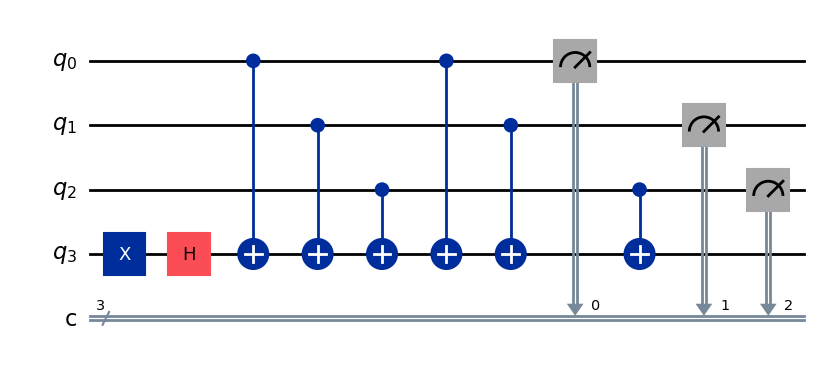

In [8]:
def deutsch_jozsa(n, oracle):
    qc = QuantumCircuit(n + 1, n)
    
    # Step 1: prepare ancilla in |-> state
    qc.x(n)
    qc.h(n)
    
    # TODO Step 2: apply H to each of the n input qubits
    #   (same pattern as Exercise 3)

    for i in range(n):
        oracle.cx(i, n)


    # Step 3: apply the oracle
    qc.compose(oracle, inplace=True)
    
    # TODO Step 4: apply H to each of the n input qubits again

    for i in range(n):
        oracle.cx(i, n)


    # Step 5: measure the input qubits
    qc.measure(range(n), range(n))
    return qc

# Build the full circuit for a balanced oracle
n = 3
dj_circuit = deutsch_jozsa(n, balanced_oracle(n))
dj_circuit.draw('mpl')


In [9]:
# Run it ONCE and see the result
result = AerSimulator().run(dj_circuit, shots=1).result()
counts = result.get_counts()
outcome = list(counts.keys())[0]

print(f'Measurement outcome: {outcome}')
if outcome == '0' * n:
    print('Diagnosis: CONSTANT function.')
else:
    print('Diagnosis: BALANCED function.')


Measurement outcome: 000
Diagnosis: CONSTANT function.


### Step 3 — Verify it works on the constant case too


In [10]:
# Try it on a constant oracle
dj_const = deutsch_jozsa(n, constant_oracle(n, value=0))
result = AerSimulator().run(dj_const, shots=1).result()
outcome = list(result.get_counts().keys())[0]

print(f'Measurement outcome: {outcome}')
if outcome == '0' * n:
    print('Diagnosis: CONSTANT function. ✓')
else:
    print('Diagnosis: BALANCED function.')


Measurement outcome: 000
Diagnosis: CONSTANT function. ✓


**What just happened?** You just ran an algorithm that's **provably exponentially faster** 
than any classical algorithm for this problem.

- Classical: could need up to $2^{n-1}+1 = 5$ queries for $n=3$. For $n=100$ it'd be 
  $\sim 2^{99}$ queries — longer than the age of the universe.
- Quantum: exactly 1 query. Always.

**How it works, conceptually:** the Hadamards create a uniform superposition of all inputs. 
The oracle is applied to that superposition — acting on all $2^n$ inputs simultaneously. 
The final Hadamards cause the amplitudes to **interfere**: if $f$ is constant, all the 
amplitudes add up at the all-zeros outcome. If $f$ is balanced, they exactly cancel at 
all-zeros and go somewhere else. Measurement reveals the pattern in one shot.

**Caveat:** Deutsch–Jozsa isn't practically useful — no one cares whether a function is 
constant or balanced. But it was the first provable quantum speedup, and it laid the 
groundwork for Shor's algorithm two years later.


---
## Bonus — if you finish early

Pick any of these:

**(a) Build your own balanced oracle.** Modify `balanced_oracle()` to implement a 
*different* balanced function — for example, flip f whenever the input is odd. 
Does Deutsch–Jozsa still give the right answer?

**(b) Visualize a qubit on the Bloch sphere.** Run the cell below — it shows where on 
the sphere your qubit lives for various rotations. Try changing the angle.

**(c) Run on real hardware.** Qiskit lets you submit to real IBM quantum computers (free 
tier available at quantum.ibm.com). Compare what comes back with your simulator results 
— the differences are decoherence and gate errors, live.

**(d) Explore interference.** The cell after (b) shows a simple two-path interference 
experiment. Play with the phase.


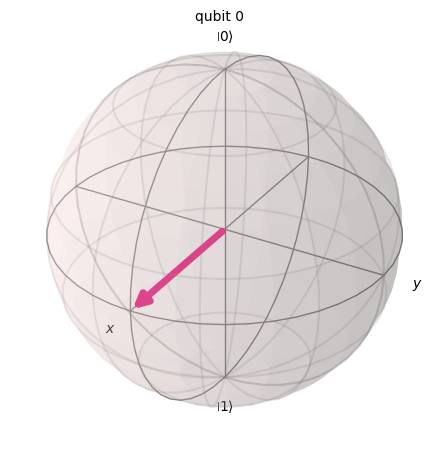

In [16]:
# (b) Bloch sphere visualization
qc = QuantumCircuit(1)
theta = np.pi/2   # try different angles
qc.ry(theta, 0)
state = Statevector.from_instruction(qc)
plot_bloch_multivector(state)


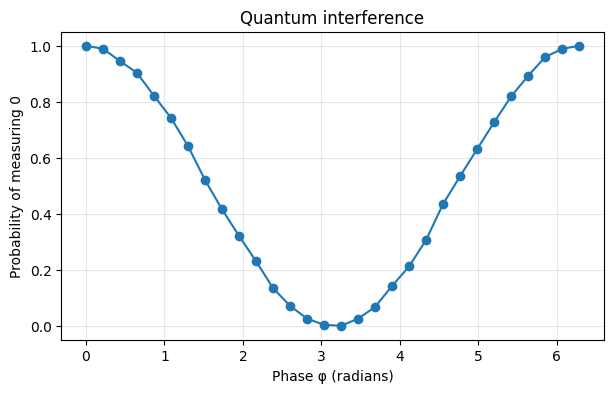

In [12]:
# (d) Interference: H, phase, H
# Two H gates in a row would give you back |0>.
# But if you put a phase between them, the two 'paths' interfere differently.

import matplotlib.pyplot as plt

phases = np.linspace(0, 2*np.pi, 30)
prob_zero = []

for phi in phases:
    qc = QuantumCircuit(1, 1)
    qc.h(0)
    qc.p(phi, 0)     # phase gate
    qc.h(0)
    qc.measure(0, 0)
    counts = AerSimulator().run(qc, shots=2000).result().get_counts()
    prob_zero.append(counts.get('0', 0) / 2000)

plt.figure(figsize=(7, 4))
plt.plot(phases, prob_zero, 'o-')
plt.xlabel('Phase φ (radians)')
plt.ylabel('Probability of measuring 0')
plt.title('Quantum interference')
plt.grid(True, alpha=0.3)
plt.show()


You should see a cosine curve — the two paths through the circuit interfere 
constructively or destructively depending on the phase. This is exactly what makes 
Deutsch–Jozsa, Grover, and Shor work: controlled interference of amplitudes.


---
## Wrap-up

You just:
- Built a qubit superposition and measured it.
- Created an entangled pair.
- Built a uniform superposition over $2^n$ states in $n$ gates.
- Implemented a real quantum algorithm with a provable speedup.

**If you want to keep going:**
- [Qiskit Textbook](https://learning.quantum.ibm.com/) — free, interactive, excellent.
- [Quirk](https://algassert.com/quirk) — drag-and-drop quantum circuit simulator in your browser. Great for intuition.
- [PennyLane demos](https://pennylane.ai/qml/demonstrations/) — quantum machine learning angle, closer to what a neuroscientist might care about.
- Nielsen & Chuang textbook — the canonical reference if you want depth.
